# Recovery Point ML Training Notebook

This notebook builds a complete machine learning workflow for **recovery point recommendation** using the training workbook:

- data loading
- data understanding
- EDA
- feature engineering
- train / validation / test split
- model training
- model comparison
- best model evaluation
- prediction examples

The target column is:

- `LABEL` with classes: `BEST`, `GOOD`, `ACCEPTABLE`, `RISKY`, `AVOID`

> Important note: this notebook trains two tracks:
>
> 1. **Leakage-safe model**: excludes rule-derived scoring columns  
> 2. **Hybrid model**: includes rule-derived score columns  
>
> The leakage-safe model is better for honest ML evaluation.  
> The hybrid model is useful when you want ML + business-rule signals together.


## 1. Imports and notebook settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


## 2. Load the Excel file

Update the path only if your file is stored somewhere else.


In [2]:
file_path = "recovery_points_training_data_v7.xlsx"
sheet_name = "Recovery Points Training Data"

df = pd.read_excel(file_path, sheet_name=sheet_name)
print("Shape:", df.shape)
display(df.head())


Shape: (1200, 14)


,ACTIVATED_PLAN_ID,GROUP_ID,COPY_TYPE,SOURCE_SYSTEM,SOURCE_TYPE,SCANNABLE,SCAN_JOB_RESULT_RAW,SCAN_JOB_RESULT,VALIDATION_SUCCESSFUL_RAW,VALIDATION_STATUS,IS_LATEST,IMMUTABLE,MALWARE_ANOMALY_DETECTED,LABEL
0,69dfdb0524e15fce77bcccbc,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,True,NaN,False,GOOD
1,69df873b24e15fce77a9c8eb,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE
2,69df32c024e15fce7796492e,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE
3,69dede3224e15fce77832c5a,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE
4,69de8c2e24e15fce77772b77,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,True,FAILED,FAILED,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE


## 3. Basic structure check

In [3]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))



Columns:
['ACTIVATED_PLAN_ID', 'GROUP_ID', 'COPY_TYPE', 'SOURCE_SYSTEM', 'SOURCE_TYPE', 'SCANNABLE', 'SCAN_JOB_RESULT_RAW', 'SCAN_JOB_RESULT', 'VALIDATION_SUCCESSFUL_RAW', 'VALIDATION_STATUS', 'IS_LATEST', 'IMMUTABLE', 'MALWARE_ANOMALY_DETECTED', 'SCORE_MALWARE', 'SCORE_SCANNER', 'SCORE_VALIDATION', 'SCORE_LATEST', 'SCORE_IMMUTABLE', 'TOTAL_SCORE', 'LABEL']

Data types:
ACTIVATED_PLAN_ID             object
GROUP_ID                      object
COPY_TYPE                     object
SOURCE_SYSTEM                 object
SOURCE_TYPE                   object
SCANNABLE                       bool
SCAN_JOB_RESULT_RAW           object
SCAN_JOB_RESULT               object
VALIDATION_SUCCESSFUL_RAW    float64
VALIDATION_STATUS             object
IS_LATEST                       bool
IMMUTABLE                    float64
MALWARE_ANOMALY_DETECTED        bool
SCORE_MALWARE                  int64
SCORE_SCANNER                  int64
SCORE_VALIDATION               int64
SCORE_LATEST                   int

,missing_count
SCAN_JOB_RESULT_RAW,392
IMMUTABLE,379
VALIDATION_SUCCESSFUL_RAW,227
ACTIVATED_PLAN_ID,0
TOTAL_SCORE,0
SCORE_IMMUTABLE,0
SCORE_LATEST,0
SCORE_VALIDATION,0
SCORE_SCANNER,0
SCORE_MALWARE,0


## 4. Quick descriptive summary

In [4]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ACTIVATED_PLAN_ID,600,600,69dfdb0524e15fce77bcccbc,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GROUP_ID,600,34,4535b2d7-62d9-481e-b8ad-9668476061dd,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COPY_TYPE,600,10,cdp,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_SYSTEM,600,7,defender-ready.storage.tucson.ibm.com,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_TYPE,600,7,cdp,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCANNABLE,600,2,False,392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCAN_JOB_RESULT_RAW,208,6,CLEAN,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCAN_JOB_RESULT,600,8,NON_SCANNABLE,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VALIDATION_SUCCESSFUL_RAW,373.0,NaN,NaN,NaN,0.324397,0.468778,0.0,0.0,0.0,1.0,1.0
VALIDATION_STATUS,600,3,INVALID,252,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Target distribution

This helps us see whether the classes are balanced or not.


,count
LABEL,
ACCEPTABLE,136
AVOID,93
BEST,59
GOOD,43
RISKY,269


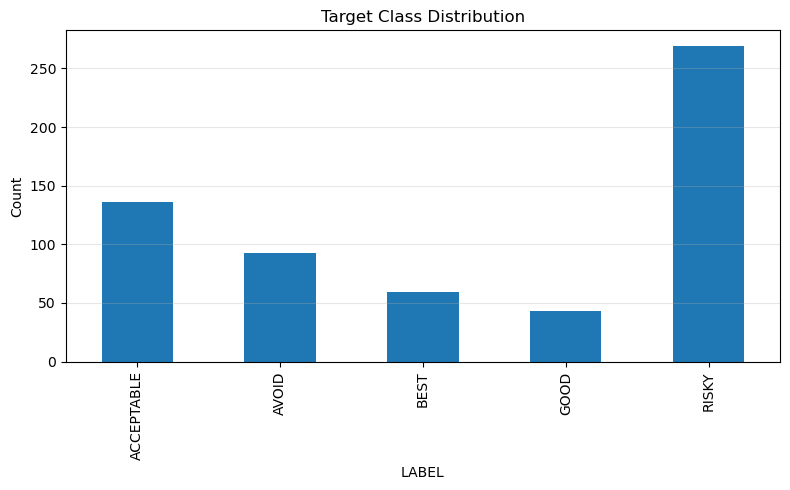

In [5]:
label_counts = df["LABEL"].value_counts().sort_index()
display(label_counts.to_frame("count"))

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("LABEL")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Unique values for important columns

In [6]:
important_cols = [
    "COPY_TYPE",
    "SOURCE_TYPE",
    "SCAN_JOB_RESULT",
    "VALIDATION_STATUS",
    "SCANNABLE",
    "IS_LATEST",
    "MALWARE_ANOMALY_DETECTED"
]

for col in important_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- COPY_TYPE ---
COPY_TYPE
cdp                 130
SAFEGUARDED_COPY    112
Backup               88
BACKUP               82
Snapshot             48
CDP                  45
Archive              43
purestorage          34
flashsystem          12
SNAPSHOT              6
Name: count, dtype: int64

--- SOURCE_TYPE ---
SOURCE_TYPE
cdp                 266
flashsystem         139
ibm_data_protect     62
tape                 49
object_store         44
purestorage          34
dellpowermax          6
Name: count, dtype: int64

--- SCAN_JOB_RESULT ---
SCAN_JOB_RESULT
NON_SCANNABLE    290
NOT_SCANNED      102
CLEAN             52
INCONCLUSIVE      36
FAILED            33
SUSPICIOUS        31
MALICIOUS         28
INFECTED          28
Name: count, dtype: int64

--- VALIDATION_STATUS ---
VALIDATION_STATUS
INVALID      252
UNKNOWN      227
VALIDATED    121
Name: count, dtype: int64

--- SCANNABLE ---
SCANNABLE
False    392
True     208
Name: count, dtype: int64

--- IS_LATEST ---
IS_LATEST
False    46

## 7. Group-level understanding

Since recommendation is made within a `GROUP_ID`, we should understand how many recovery points exist per group.


,group_size_stats
count,34.000000
mean,17.647059
std,15.393588
min,4.000000
25%,10.000000
50%,12.000000
75%,18.000000
max,84.000000


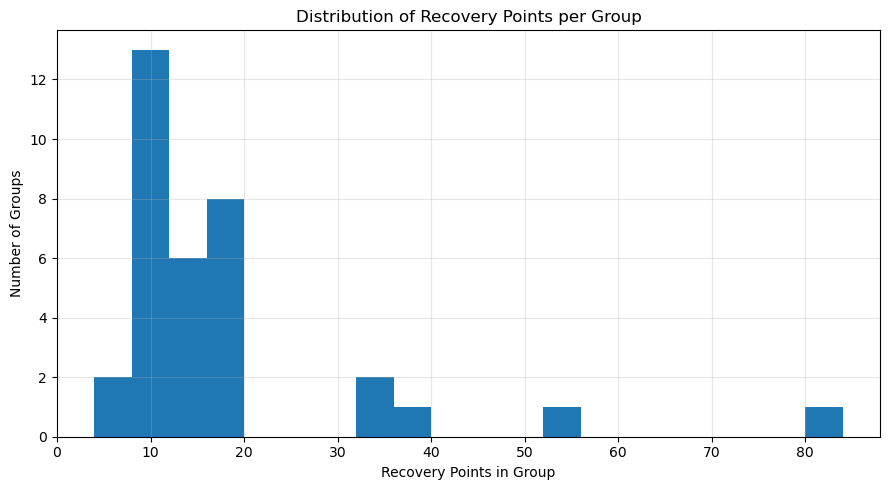

,recovery_points_per_group
GROUP_ID,
4535b2d7-62d9-481e-b8ad-9668476061dd,84
a896780a-5345-439a-a5db-b929f493fe13,54
6d3118e8-c045-4275-809d-0bcf525d7122,38
209387af-b1ce-4195-8d8c-31f364f4b6a0,34
92d63158-552e-480b-939c-32bcf24488bd,32
grp-fill-001,18
grp-fill-005,18
grp-fill-004,18
grp-fill-003,18


In [7]:
group_size = df.groupby("GROUP_ID").size().sort_values(ascending=False)

display(group_size.describe().to_frame("group_size_stats"))

plt.figure(figsize=(9, 5))
plt.hist(group_size.values, bins=min(20, len(group_size)))
plt.title("Distribution of Recovery Points per Group")
plt.xlabel("Recovery Points in Group")
plt.ylabel("Number of Groups")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(group_size.head(20).to_frame("recovery_points_per_group"))


## 8. Missing value visualization

This is a compact missing-value percentage view.


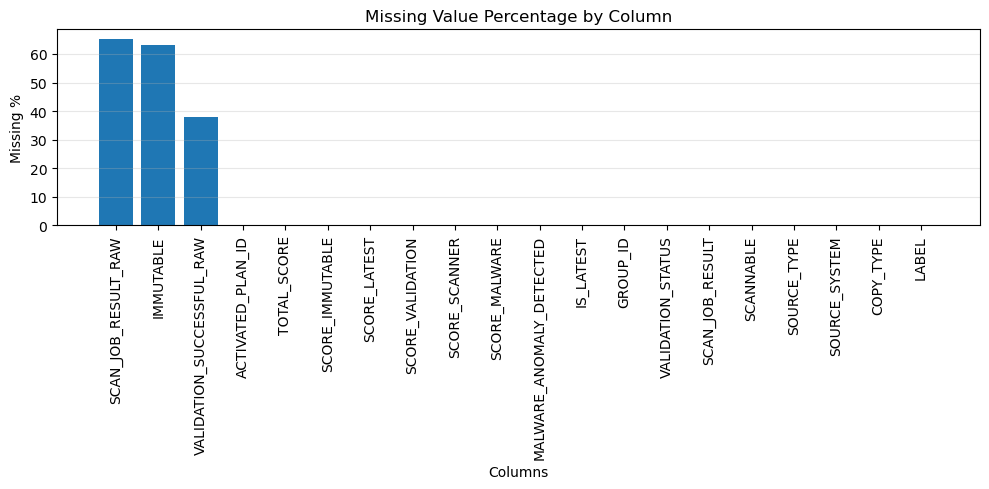

,missing_percent
SCAN_JOB_RESULT_RAW,65.333333
IMMUTABLE,63.166667
VALIDATION_SUCCESSFUL_RAW,37.833333
ACTIVATED_PLAN_ID,0.000000
TOTAL_SCORE,0.000000
SCORE_IMMUTABLE,0.000000
SCORE_LATEST,0.000000
SCORE_VALIDATION,0.000000
SCORE_SCANNER,0.000000
SCORE_MALWARE,0.000000


In [8]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Missing Value Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Missing %")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(missing_pct.to_frame("missing_percent"))


## 9. Relationship checks with target

These plots help us understand how the target changes by key business signals.


LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
SCAN_JOB_RESULT,,,,,
CLEAN,0,5,25,7,15
FAILED,4,4,4,6,15
INCONCLUSIVE,0,4,12,8,12
INFECTED,0,19,0,0,9
MALICIOUS,0,20,0,0,8
NON_SCANNABLE,89,14,7,10,170
NOT_SCANNED,43,8,11,12,28
SUSPICIOUS,0,19,0,0,12


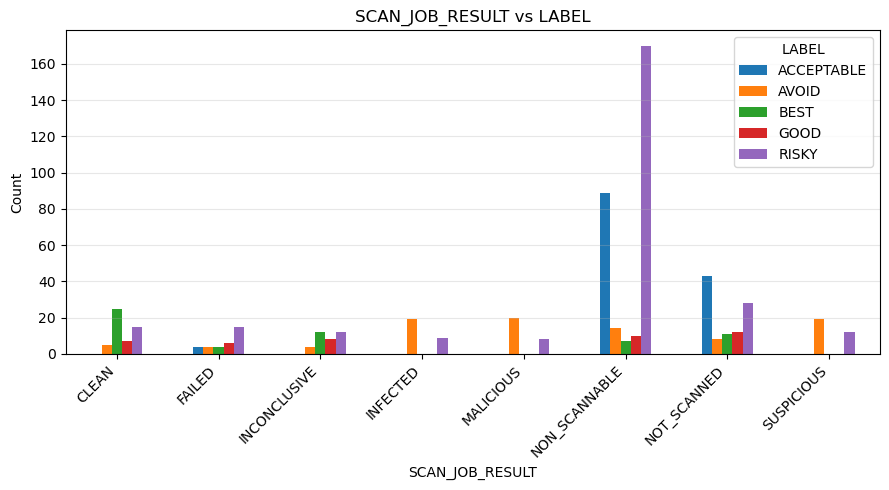

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
VALIDATION_STATUS,,,,,
INVALID,0,56,0,0,196
UNKNOWN,136,15,5,33,38
VALIDATED,0,22,54,10,35


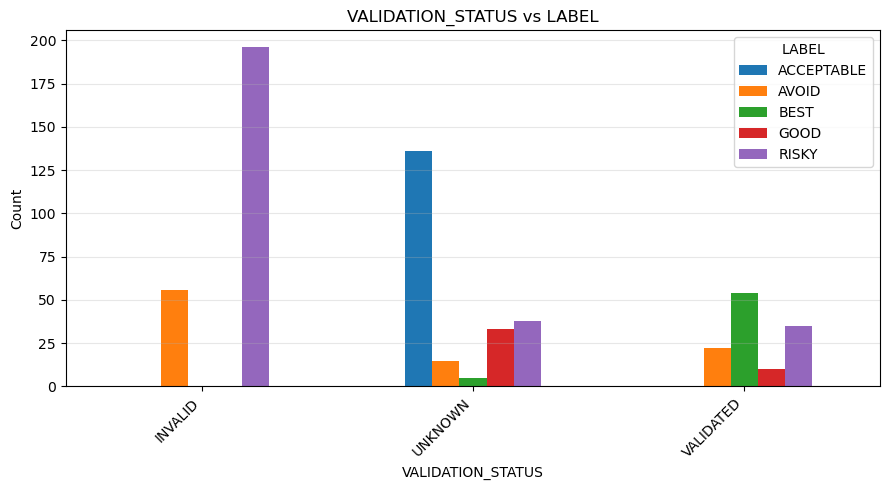

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
COPY_TYPE,,,,,
Archive,1,18,7,1,16
BACKUP,80,0,0,2,0
Backup,5,17,21,15,30
CDP,1,10,6,8,20
SAFEGUARDED_COPY,44,16,21,14,17
SNAPSHOT,5,0,0,1,0
Snapshot,0,21,4,2,21
cdp,0,6,0,0,124
flashsystem,0,2,0,0,10


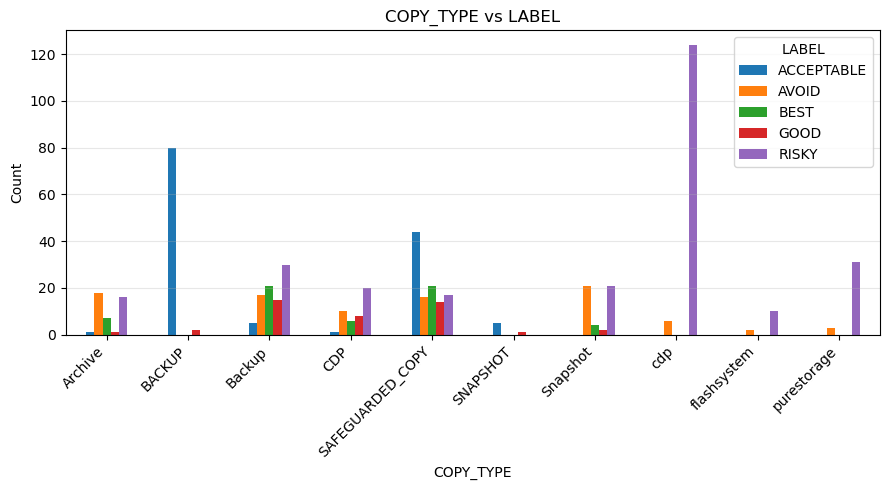

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
SOURCE_TYPE,,,,,
cdp,81,23,6,9,147
dellpowermax,5,0,0,1,0
flashsystem,44,27,26,14,28
ibm_data_protect,3,14,16,9,20
object_store,0,16,4,3,21
purestorage,0,3,0,0,31
tape,3,10,7,7,22


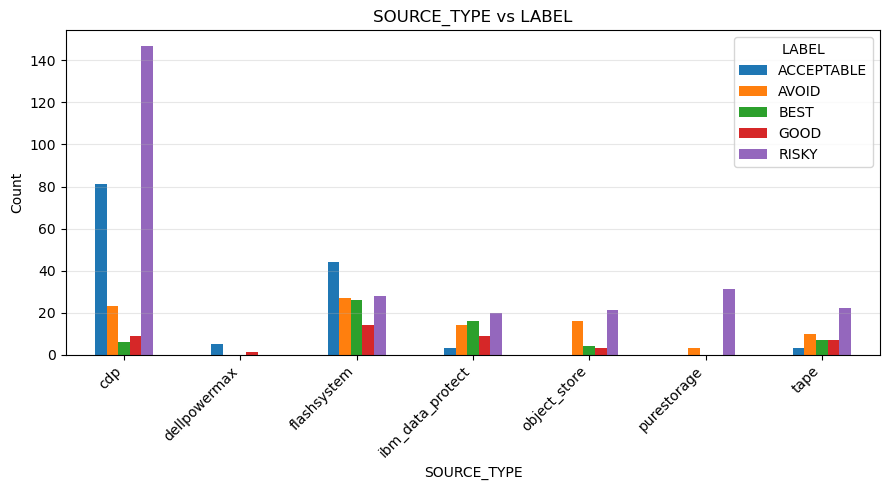

In [9]:
eda_cols = ["SCAN_JOB_RESULT", "VALIDATION_STATUS", "COPY_TYPE", "SOURCE_TYPE"]

for col in eda_cols:
    ctab = pd.crosstab(df[col], df["LABEL"])
    display(ctab)

    ax = ctab.plot(kind="bar", figsize=(9, 5))
    plt.title(f"{col} vs LABEL")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 10. Score-based distributions

These score columns come from business-rule logic.  
They are very useful for analysis, but they can also create leakage if used blindly in ML.


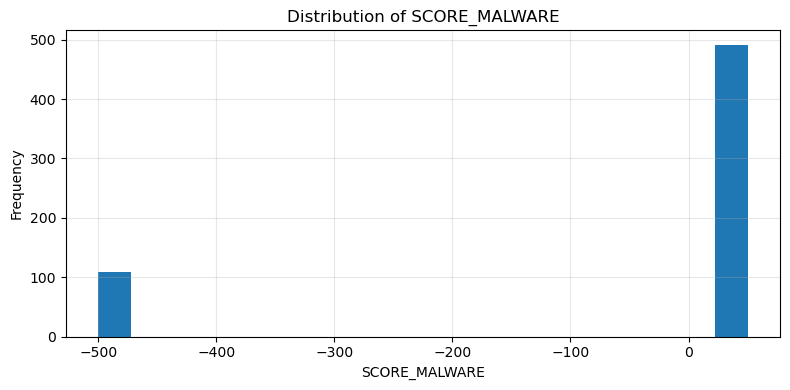

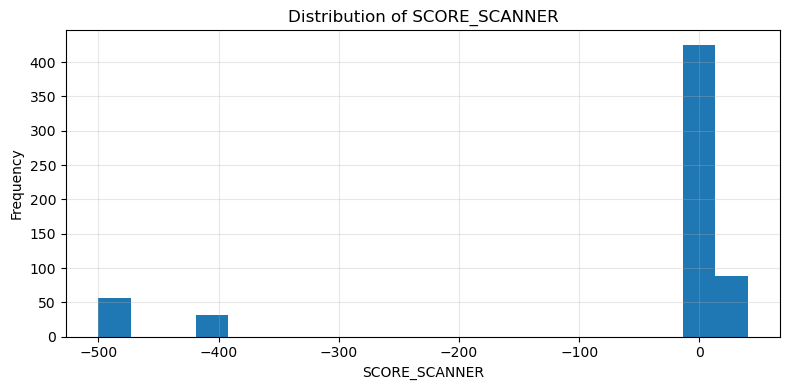

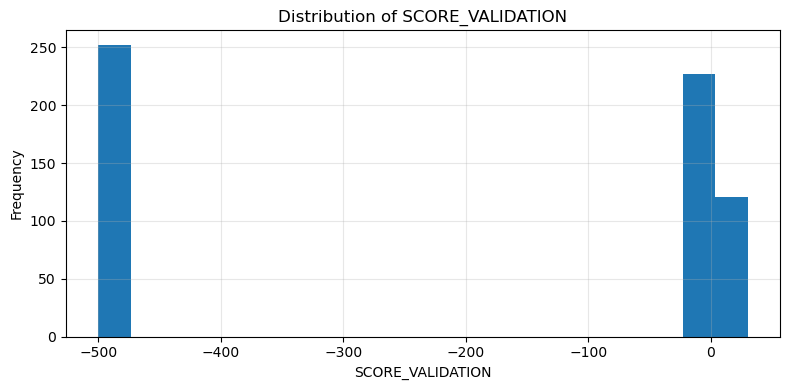

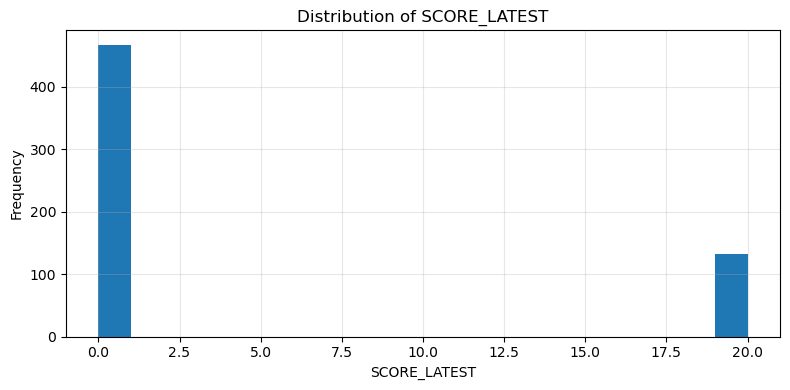

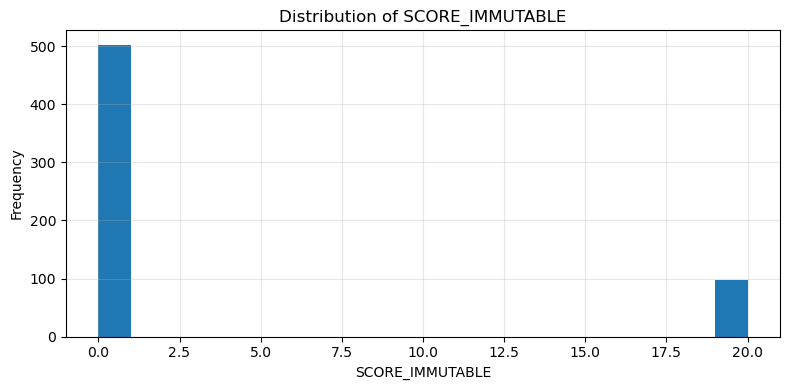

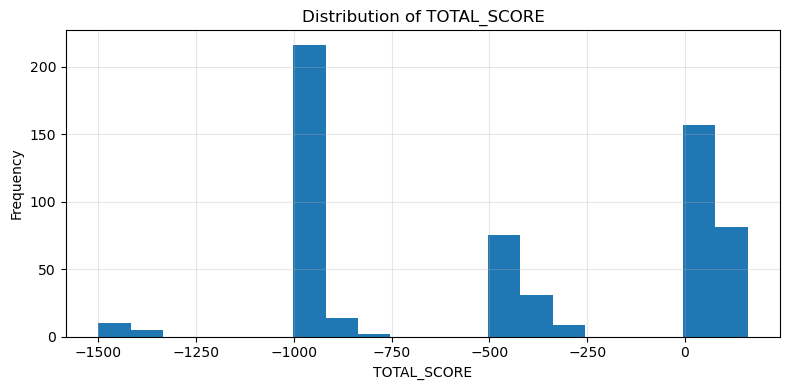

In [10]:
score_cols = [
    "SCORE_MALWARE",
    "SCORE_SCANNER",
    "SCORE_VALIDATION",
    "SCORE_LATEST",
    "SCORE_IMMUTABLE",
    "TOTAL_SCORE",
]

for col in score_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 11. Total score by class

This checks whether the business scoring aligns with the target labels.


,count,mean,median,min,max
LABEL,,,,,
ACCEPTABLE,136,50.000000,50.0,50,50
AVOID,93,-967.849462,-960.0,-1500,-450
BEST,59,119.491525,120.0,100,160
GOOD,43,77.906977,80.0,70,90
RISKY,269,-778.029740,-1000.0,-1000,-280


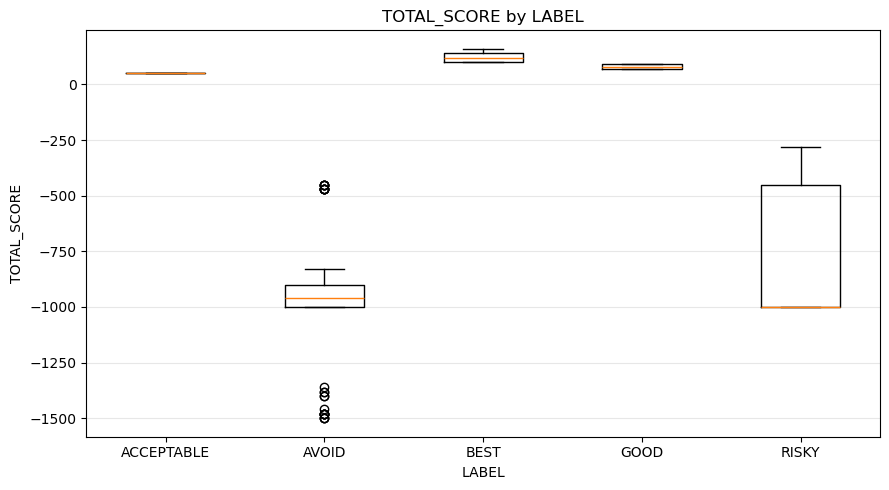

In [11]:
score_by_label = df.groupby("LABEL")["TOTAL_SCORE"].agg(["count", "mean", "median", "min", "max"]).sort_index()
display(score_by_label)

plt.figure(figsize=(9, 5))
data_to_plot = [df.loc[df["LABEL"] == label, "TOTAL_SCORE"].values for label in sorted(df["LABEL"].unique())]
plt.boxplot(data_to_plot, tick_labels=sorted(df["LABEL"].unique()))
plt.title("TOTAL_SCORE by LABEL")
plt.xlabel("LABEL")
plt.ylabel("TOTAL_SCORE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Data cleaning and feature preparation

We create a modeling copy of the dataset and handle missing values intentionally.

### Business interpretation applied
- Missing validation information stays conceptually as **NOT_VALIDATED**
- Missing immutable stays as **UNKNOWN**
- Raw boolean-like fields are converted into readable categories where useful


In [12]:
model_df = df.copy()

model_df["IMMUTABLE_FLAG"] = model_df["IMMUTABLE"].map({1.0: "TRUE", 0.0: "FALSE"})
model_df["IMMUTABLE_FLAG"] = model_df["IMMUTABLE_FLAG"].fillna("UNKNOWN")

model_df["VALIDATION_SUCCESSFUL_FLAG"] = model_df["VALIDATION_SUCCESSFUL_RAW"].map({1.0: "TRUE", 0.0: "FALSE"})
model_df["VALIDATION_SUCCESSFUL_FLAG"] = model_df["VALIDATION_SUCCESSFUL_FLAG"].fillna("UNKNOWN")

model_df["SCAN_JOB_RESULT_RAW"] = model_df["SCAN_JOB_RESULT_RAW"].fillna("MISSING")
model_df["SOURCE_SYSTEM"] = model_df["SOURCE_SYSTEM"].fillna("UNKNOWN")
model_df["SOURCE_TYPE"] = model_df["SOURCE_TYPE"].fillna("UNKNOWN")
model_df["COPY_TYPE"] = model_df["COPY_TYPE"].fillna("UNKNOWN")
model_df["SCAN_JOB_RESULT"] = model_df["SCAN_JOB_RESULT"].fillna("UNKNOWN")
model_df["VALIDATION_STATUS"] = model_df["VALIDATION_STATUS"].fillna("NOT_VALIDATED")

display(model_df.head())


,ACTIVATED_PLAN_ID,GROUP_ID,COPY_TYPE,SOURCE_SYSTEM,SOURCE_TYPE,SCANNABLE,SCAN_JOB_RESULT_RAW,SCAN_JOB_RESULT,VALIDATION_SUCCESSFUL_RAW,VALIDATION_STATUS,IS_LATEST,IMMUTABLE,MALWARE_ANOMALY_DETECTED,SCORE_MALWARE,SCORE_SCANNER,SCORE_VALIDATION,SCORE_LATEST,SCORE_IMMUTABLE,TOTAL_SCORE,LABEL,IMMUTABLE_FLAG,VALIDATION_SUCCESSFUL_FLAG
0,69dfdb0524e15fce77bcccbc,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,MISSING,NOT_SCANNED,NaN,UNKNOWN,True,NaN,False,50,0,0,20,0,70,GOOD,UNKNOWN,UNKNOWN
1,69df873b24e15fce77a9c8eb,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,MISSING,NOT_SCANNED,NaN,UNKNOWN,False,NaN,False,50,0,0,0,0,50,ACCEPTABLE,UNKNOWN,UNKNOWN
2,69df32c024e15fce7796492e,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,MISSING,NOT_SCANNED,NaN,UNKNOWN,False,NaN,False,50,0,0,0,0,50,ACCEPTABLE,UNKNOWN,UNKNOWN
3,69dede3224e15fce77832c5a,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,MISSING,NOT_SCANNED,NaN,UNKNOWN,False,NaN,False,50,0,0,0,0,50,ACCEPTABLE,UNKNOWN,UNKNOWN
4,69de8c2e24e15fce77772b77,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,True,FAILED,FAILED,NaN,UNKNOWN,False,NaN,False,50,0,0,0,0,50,ACCEPTABLE,UNKNOWN,UNKNOWN


## 13. Define two feature sets

### A. Leakage-safe features
Use only original business attributes and categorical states.

### B. Hybrid features
Use business attributes + score columns.

The target remains:
- `LABEL`


In [13]:
target_col = "LABEL"

leakage_safe_features = [
    "COPY_TYPE",
    "SOURCE_SYSTEM",
    "SOURCE_TYPE",
    "SCANNABLE",
    "SCAN_JOB_RESULT_RAW",
    "SCAN_JOB_RESULT",
    "VALIDATION_SUCCESSFUL_FLAG",
    "VALIDATION_STATUS",
    "IS_LATEST",
    "IMMUTABLE_FLAG",
    "MALWARE_ANOMALY_DETECTED",
]

hybrid_features = leakage_safe_features + [
    "SCORE_MALWARE",
    "SCORE_SCANNER",
    "SCORE_VALIDATION",
    "SCORE_LATEST",
    "SCORE_IMMUTABLE",
    "TOTAL_SCORE",
]

print("Leakage-safe feature count:", len(leakage_safe_features))
print("Hybrid feature count:", len(hybrid_features))


Leakage-safe feature count: 11
Hybrid feature count: 17


## 14. Train / validation / test split

We first split into:
- train = 70%
- validation = 15%
- test = 15%

Stratification is used to preserve class proportions.


In [14]:
X_safe = model_df[leakage_safe_features].copy()
X_hybrid = model_df[hybrid_features].copy()
y = model_df[target_col].copy()

X_safe_train, X_safe_temp, y_train, y_temp = train_test_split(
    X_safe, y, test_size=0.30, stratify=y, random_state=42
)

X_safe_val, X_safe_test, y_val, y_test = train_test_split(
    X_safe_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

X_hybrid_train = X_hybrid.loc[X_safe_train.index]
X_hybrid_val = X_hybrid.loc[X_safe_val.index]
X_hybrid_test = X_hybrid.loc[X_safe_test.index]

print("Train shape:", X_safe_train.shape, y_train.shape)
print("Validation shape:", X_safe_val.shape, y_val.shape)
print("Test shape:", X_safe_test.shape, y_test.shape)


Train shape: (420, 11) (420,)
Validation shape: (90, 11) (90,)
Test shape: (90, 11) (90,)


## 15. Preprocessing pipelines

We one-hot encode categorical features and pass numeric features through.


In [15]:
safe_categorical_cols = X_safe_train.select_dtypes(include=["object", "bool"]).columns.tolist()
safe_numeric_cols = X_safe_train.select_dtypes(include=["number"]).columns.tolist()

hybrid_categorical_cols = X_hybrid_train.select_dtypes(include=["object", "bool"]).columns.tolist()
hybrid_numeric_cols = X_hybrid_train.select_dtypes(include=["number"]).columns.tolist()

safe_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), safe_categorical_cols),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), safe_numeric_cols),
    ]
)

hybrid_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), hybrid_categorical_cols),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), hybrid_numeric_cols),
    ]
)

print("Safe categorical:", safe_categorical_cols)
print("Safe numeric:", safe_numeric_cols)
print("Hybrid categorical:", hybrid_categorical_cols)
print("Hybrid numeric:", hybrid_numeric_cols)


Safe categorical: ['COPY_TYPE', 'SOURCE_SYSTEM', 'SOURCE_TYPE', 'SCANNABLE', 'SCAN_JOB_RESULT_RAW', 'SCAN_JOB_RESULT', 'VALIDATION_SUCCESSFUL_FLAG', 'VALIDATION_STATUS', 'IS_LATEST', 'IMMUTABLE_FLAG', 'MALWARE_ANOMALY_DETECTED']
Safe numeric: []
Hybrid categorical: ['COPY_TYPE', 'SOURCE_SYSTEM', 'SOURCE_TYPE', 'SCANNABLE', 'SCAN_JOB_RESULT_RAW', 'SCAN_JOB_RESULT', 'VALIDATION_SUCCESSFUL_FLAG', 'VALIDATION_STATUS', 'IS_LATEST', 'IMMUTABLE_FLAG', 'MALWARE_ANOMALY_DETECTED']
Hybrid numeric: ['SCORE_MALWARE', 'SCORE_SCANNER', 'SCORE_VALIDATION', 'SCORE_LATEST', 'SCORE_IMMUTABLE', 'TOTAL_SCORE']


## 16. Model list

We compare a few strong baseline models for tabular classification.


In [16]:
model_dict = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced_subsample"
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}


## 17. Training helper function

In [17]:
def evaluate_models(X_train, y_train, X_val, y_val, preprocessor, models, track_name="TRACK"):
    results = []
    fitted_models = {}

    for model_name, model in models.items():
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        val_pred = pipe.predict(X_val)

        row = {
            "TRACK": track_name,
            "MODEL": model_name,
            "VAL_ACCURACY": accuracy_score(y_val, val_pred),
            "VAL_F1_WEIGHTED": f1_score(y_val, val_pred, average="weighted"),
            "VAL_F1_MACRO": f1_score(y_val, val_pred, average="macro"),
        }

        results.append(row)
        fitted_models[model_name] = pipe

        print(f"Finished: {track_name} - {model_name}")

    results_df = pd.DataFrame(results).sort_values(
        by=["VAL_F1_WEIGHTED", "VAL_F1_MACRO", "VAL_ACCURACY"],
        ascending=False
    ).reset_index(drop=True)

    return results_df, fitted_models


## 18. Train the leakage-safe models

In [18]:
safe_results, safe_fitted = evaluate_models(
    X_safe_train, y_train, X_safe_val, y_val,
    safe_preprocessor, model_dict, track_name="LEAKAGE_SAFE"
)

display(safe_results)


Finished: LEAKAGE_SAFE - LogisticRegression
Finished: LEAKAGE_SAFE - RandomForest
Finished: LEAKAGE_SAFE - ExtraTrees
Finished: LEAKAGE_SAFE - GradientBoosting


,TRACK,MODEL,VAL_ACCURACY,VAL_F1_WEIGHTED,VAL_F1_MACRO
0,LEAKAGE_SAFE,GradientBoosting,0.966667,0.966487,0.943964
1,LEAKAGE_SAFE,ExtraTrees,0.944444,0.947422,0.922779
2,LEAKAGE_SAFE,LogisticRegression,0.922222,0.923286,0.908385
3,LEAKAGE_SAFE,RandomForest,0.900000,0.903194,0.871053


## 19. Train the hybrid models

In [19]:
hybrid_results, hybrid_fitted = evaluate_models(
    X_hybrid_train, y_train, X_hybrid_val, y_val,
    hybrid_preprocessor, model_dict, track_name="HYBRID"
)

display(hybrid_results)


Finished: HYBRID - LogisticRegression
Finished: HYBRID - RandomForest
Finished: HYBRID - ExtraTrees
Finished: HYBRID - GradientBoosting


,TRACK,MODEL,VAL_ACCURACY,VAL_F1_WEIGHTED,VAL_F1_MACRO
0,HYBRID,RandomForest,1.000000,1.000000,1.000000
1,HYBRID,GradientBoosting,1.000000,1.000000,1.000000
2,HYBRID,ExtraTrees,0.977778,0.978156,0.961804
3,HYBRID,LogisticRegression,0.966667,0.967030,0.971715


## 20. Compare both tracks together

,TRACK,MODEL,VAL_ACCURACY,VAL_F1_WEIGHTED,VAL_F1_MACRO
0,LEAKAGE_SAFE,GradientBoosting,0.966667,0.966487,0.943964
1,LEAKAGE_SAFE,ExtraTrees,0.944444,0.947422,0.922779
2,LEAKAGE_SAFE,LogisticRegression,0.922222,0.923286,0.908385
3,LEAKAGE_SAFE,RandomForest,0.900000,0.903194,0.871053
4,HYBRID,RandomForest,1.000000,1.000000,1.000000
5,HYBRID,GradientBoosting,1.000000,1.000000,1.000000
6,HYBRID,ExtraTrees,0.977778,0.978156,0.961804
7,HYBRID,LogisticRegression,0.966667,0.967030,0.971715


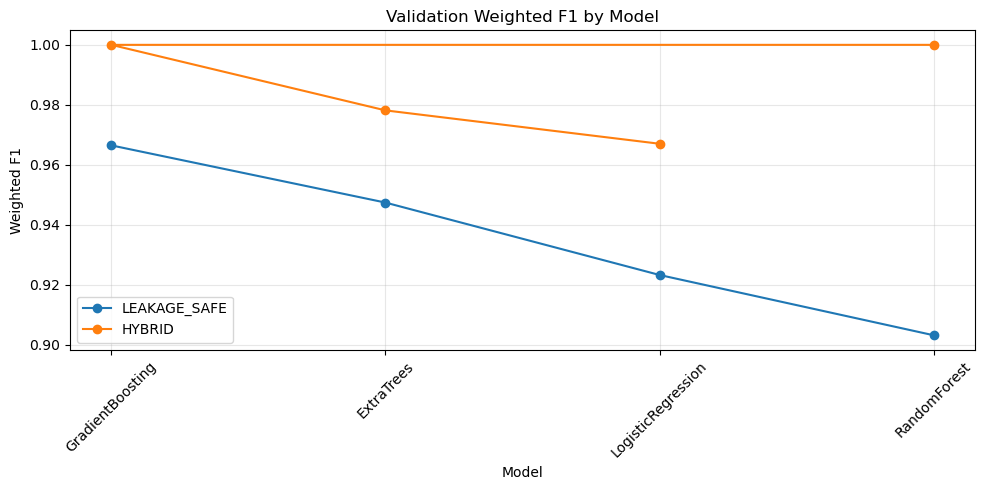

In [20]:
all_results = pd.concat([safe_results, hybrid_results], axis=0).reset_index(drop=True)
display(all_results)

plt.figure(figsize=(10, 5))
for track in all_results["TRACK"].unique():
    subset = all_results[all_results["TRACK"] == track]
    plt.plot(subset["MODEL"], subset["VAL_F1_WEIGHTED"], marker="o", label=track)

plt.title("Validation Weighted F1 by Model")
plt.xlabel("Model")
plt.ylabel("Weighted F1")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 21. Select the best validation model

You can choose:
- best leakage-safe model for more honest ML
- best hybrid model for stronger operational performance


In [21]:
best_safe_name = safe_results.iloc[0]["MODEL"]
best_hybrid_name = hybrid_results.iloc[0]["MODEL"]

best_safe_model = safe_fitted[best_safe_name]
best_hybrid_model = hybrid_fitted[best_hybrid_name]

print("Best leakage-safe model:", best_safe_name)
print("Best hybrid model:", best_hybrid_name)


Best leakage-safe model: GradientBoosting
Best hybrid model: RandomForest


## 22. Confusion matrix on validation set

First for the best leakage-safe model.


In [22]:
safe_val_pred = best_safe_model.predict(X_safe_val)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, safe_val_pred, ax=ax, xticks_rotation=45
)
plt.title(f"Validation Confusion Matrix - Leakage-Safe ({best_safe_name})")
plt.tight_layout()
plt.show()

print(classification_report(y_val, safe_val_pred))


ValueError: X has 54 features, but GradientBoostingClassifier is expecting 60 features as input.

## 23. Confusion matrix on validation set for the hybrid model

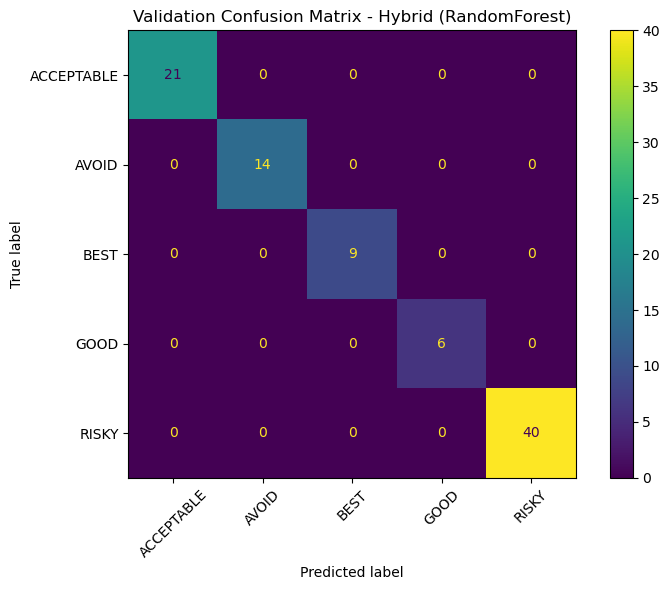

              precision    recall  f1-score   support

  ACCEPTABLE       1.00      1.00      1.00        21
       AVOID       1.00      1.00      1.00        14
        BEST       1.00      1.00      1.00         9
        GOOD       1.00      1.00      1.00         6
       RISKY       1.00      1.00      1.00        40

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [23]:
hybrid_val_pred = best_hybrid_model.predict(X_hybrid_val)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, hybrid_val_pred, ax=ax, xticks_rotation=45
)
plt.title(f"Validation Confusion Matrix - Hybrid ({best_hybrid_name})")
plt.tight_layout()
plt.show()

print(classification_report(y_val, hybrid_val_pred))


## 24. Retrain the chosen model on train + validation

Usually after model selection, we combine train + validation and evaluate once on the untouched test set.


In [30]:
chosen_track = "HYBRID"   # change to "LEAKAGE_SAFE" if you want the honest model
chosen_model_name = best_hybrid_name if chosen_track == "HYBRID" else best_safe_name
chosen_model = model_dict[chosen_model_name]

if chosen_track == "HYBRID":
    X_train_full = pd.concat([X_hybrid_train, X_hybrid_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)
    X_final_test = X_hybrid_test.copy()
    final_preprocessor = hybrid_preprocessor
else:
    X_train_full = pd.concat([X_safe_train, X_safe_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)
    X_final_test = X_safe_test.copy()
    final_preprocessor = safe_preprocessor

final_model = Pipeline([
    ("preprocessor", final_preprocessor),
    ("model", chosen_model)
])

final_model.fit(X_train_full, y_train_full)
test_pred = final_model.predict(X_final_test)

print("Chosen track:", chosen_track)
print("Chosen model:", chosen_model_name)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print("Test weighted F1:", f1_score(y_test, test_pred, average="weighted"))
print("Test macro F1:", f1_score(y_test, test_pred, average="macro"))


Chosen track: HYBRID
Chosen model: RandomForest
Test accuracy: 1.0
Test weighted F1: 1.0
Test macro F1: 1.0


## 25. Final test confusion matrix and report

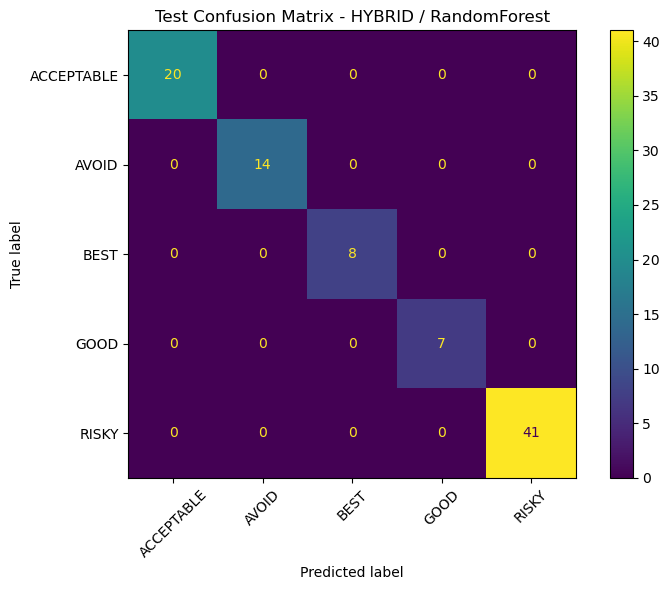

              precision    recall  f1-score   support

  ACCEPTABLE       1.00      1.00      1.00        20
       AVOID       1.00      1.00      1.00        14
        BEST       1.00      1.00      1.00         8
        GOOD       1.00      1.00      1.00         7
       RISKY       1.00      1.00      1.00        41

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, ax=ax, xticks_rotation=45
)
plt.title(f"Test Confusion Matrix - {chosen_track} / {chosen_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred))


## 26. Feature importance using permutation importance

This works for the final fitted pipeline and shows which features matter most.


,FEATURE,IMPORTANCE_MEAN,IMPORTANCE_STD
16,TOTAL_SCORE,0.075163,0.015928
10,MALWARE_ANOMALY_DETECTED,0.070810,0.016397
7,VALIDATION_STATUS,0.018983,0.011270
6,VALIDATION_SUCCESSFUL_FLAG,0.014490,0.008682
8,IS_LATEST,0.013145,0.006443
9,IMMUTABLE_FLAG,0.008716,0.008126
12,SCORE_SCANNER,0.006716,0.007437
4,SCAN_JOB_RESULT_RAW,0.006667,0.005443
3,SCANNABLE,0.006667,0.005443
13,SCORE_VALIDATION,0.004589,0.005620


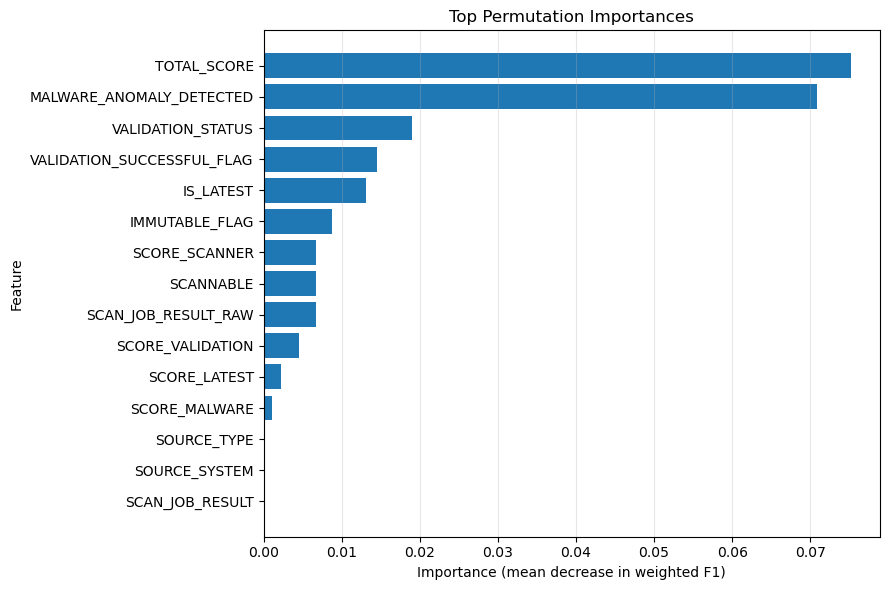

In [26]:
perm = permutation_importance(
    final_model,
    X_final_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

importance_df = pd.DataFrame({
    "FEATURE": X_train_full.columns,
    "IMPORTANCE_MEAN": perm.importances_mean,
    "IMPORTANCE_STD": perm.importances_std
}).sort_values("IMPORTANCE_MEAN", ascending=False)

display(importance_df.head(20))

top_n = 15
plot_df = importance_df.head(top_n).sort_values("IMPORTANCE_MEAN")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["FEATURE"], plot_df["IMPORTANCE_MEAN"])
plt.title("Top Permutation Importances")
plt.xlabel("Importance (mean decrease in weighted F1)")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 27. Predict class probabilities for test rows

This is useful when later you want to rank recovery points inside a group.


In [27]:
if hasattr(final_model.named_steps["model"], "predict_proba"):
    proba = final_model.predict_proba(X_final_test)
    proba_df = pd.DataFrame(proba, columns=final_model.named_steps["model"].classes_, index=X_final_test.index)

    prediction_output = model_df.loc[X_final_test.index, ["GROUP_ID", "ACTIVATED_PLAN_ID", "TOTAL_SCORE", "LABEL"]].copy()
    prediction_output["PREDICTED_LABEL"] = test_pred

    for cls in proba_df.columns:
        prediction_output[f"PROBA_{cls}"] = proba_df[cls].values

    display(prediction_output.head(20))
else:
    print("This model does not support predict_proba.")


,GROUP_ID,ACTIVATED_PLAN_ID,TOTAL_SCORE,LABEL,PREDICTED_LABEL,PROBA_ACCEPTABLE,PROBA_AVOID,PROBA_BEST,PROBA_GOOD,PROBA_RISKY
313,grp-flash-prod-001,ap-001-b62ddbd215,120,BEST,BEST,0.001411,0.000508,0.960759,0.026837,0.010485
367,grp-clean-006,ap-006-c2f8a006c6,100,BEST,BEST,0.000300,0.001795,0.958257,0.031768,0.007880
66,a896780a-5345-439a-a5db-b929f493fe13,69dc600324e15fce7734b941,50,ACCEPTABLE,ACCEPTABLE,0.981626,0.000796,0.000142,0.016658,0.000778
510,grp-fill-004,ap-937298d1f1,-480,RISKY,RISKY,0.026437,0.074383,0.004093,0.158525,0.736562
518,grp-fill-004,ap-21bc0250ad,-830,AVOID,AVOID,0.000000,0.824616,0.000779,0.001126,0.173480
103,6d3118e8-c045-4275-809d-0bcf525d7122,69e1476424e15fce771783c1,50,ACCEPTABLE,ACCEPTABLE,0.977889,0.001149,0.000142,0.019531,0.001290
452,grp-failed-scan-014,ap-014-f828b2648e,70,GOOD,GOOD,0.074460,0.016507,0.100310,0.705554,0.103169
128,6d3118e8-c045-4275-809d-0bcf525d7122,69e1476424e15fce771783a8,50,ACCEPTABLE,ACCEPTABLE,0.977889,0.001149,0.000142,0.019531,0.001290
200,4535b2d7-62d9-481e-b8ad-9668476061dd,69812710697d5378eda5dd51,-1000,RISKY,RISKY,0.000000,0.004470,0.000000,0.000000,0.995530
556,grp-fill-002,ap-1d972f78f9,-940,AVOID,AVOID,0.000000,0.916881,0.004154,0.002312,0.076653


## 28. Example: best predicted recovery point within each group

This is the first version of group-level recommendation.

Priority used:
1. highest predicted probability of `BEST`
2. if tie, highest `TOTAL_SCORE`


In [28]:
if hasattr(final_model.named_steps["model"], "predict_proba"):
    full_X = model_df[hybrid_features].copy() if chosen_track == "HYBRID" else model_df[leakage_safe_features].copy()
    full_pred = final_model.predict(full_X)
    full_proba = final_model.predict_proba(full_X)

    full_pred_df = model_df[["GROUP_ID", "ACTIVATED_PLAN_ID", "TOTAL_SCORE", "LABEL"]].copy()
    full_pred_df["PREDICTED_LABEL"] = full_pred

    proba_full_df = pd.DataFrame(full_proba, columns=final_model.named_steps["model"].classes_, index=full_pred_df.index)

    if "BEST" in proba_full_df.columns:
        full_pred_df["PRED_BEST_PROBA"] = proba_full_df["BEST"].values
    else:
        full_pred_df["PRED_BEST_PROBA"] = 0.0

    best_per_group = (
        full_pred_df
        .sort_values(["GROUP_ID", "PRED_BEST_PROBA", "TOTAL_SCORE"], ascending=[True, False, False])
        .groupby("GROUP_ID", as_index=False)
        .first()
    )

    display(best_per_group.head(20))
else:
    print("This model does not support predict_proba.")


,GROUP_ID,ACTIVATED_PLAN_ID,TOTAL_SCORE,LABEL,PREDICTED_LABEL,PRED_BEST_PROBA
0,209387af-b1ce-4195-8d8c-31f364f4b6a0,69724a0c62dcdd3fcf291fb2,-450,AVOID,AVOID,0.177319
1,2566ca97-cdfb-4800-af84-3070b5ff679c,6981447a697d5378edd673e8,-450,AVOID,AVOID,0.152633
2,3df29a5f-3341-43a2-b532-617a51c1f1cd,69dfdb0524e15fce77bcccbc,70,GOOD,GOOD,0.016182
3,4535b2d7-62d9-481e-b8ad-9668476061dd,69817cd8697d5378ed2eb139,-450,AVOID,AVOID,0.152633
4,6d3118e8-c045-4275-809d-0bcf525d7122,69e1476424e15fce771783c7,70,GOOD,GOOD,0.011580
5,736c0c92-0e9c-449c-acf6-b206226ee7f5,69cd3a5981846fa56123def6,70,GOOD,GOOD,0.007632
6,78d18dca-0462-4220-b5b7-796114967402,69df872624e15fce77a9c529,90,GOOD,GOOD,0.034882
7,7a5022ef-01a3-4de4-b932-4a8bbbdf4f75,69e1422724e15fce771767fa,70,GOOD,GOOD,0.013925
8,92d63158-552e-480b-939c-32bcf24488bd,6980f355697d5378ed4e8f06,-450,AVOID,AVOID,0.152633
9,a896780a-5345-439a-a5db-b929f493fe13,69e12edc24e15fce77133994,100,BEST,BEST,0.823115


## 29. Save prediction artifacts

This exports:
- model evaluation results
- best-per-group output

You can extend this later with `joblib.dump()` to save the trained model.


In [29]:
output_file = "ml_training_results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    safe_results.to_excel(writer, sheet_name="safe_results", index=False)
    hybrid_results.to_excel(writer, sheet_name="hybrid_results", index=False)
    all_results.to_excel(writer, sheet_name="all_results", index=False)

    if "importance_df" in globals():
        importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    if "prediction_output" in globals():
        prediction_output.to_excel(writer, sheet_name="test_predictions", index=False)

    if "best_per_group" in globals():
        best_per_group.to_excel(writer, sheet_name="best_per_group", index=False)

print("Saved:", output_file)


Saved: ml_training_results.xlsx


## 30. Optional: save the trained model

Uncomment this block when you want to persist the model for later prediction API or app integration.


In [ ]:
# import joblib
# joblib.dump(final_model, "recovery_point_classifier.joblib")
# print("Saved model: recovery_point_classifier.joblib")


## 31. Final notes

### Recommended interpretation
- Use the **leakage-safe track** when you want a fair ML benchmark
- Use the **hybrid track** when business-score features are officially part of your decision pipeline

### What we can do next
In the next phase, we can build a separate prediction notebook or Python program that:
1. takes a user's recovery-group recovery points as input
2. applies the same feature engineering
3. predicts labels for each recovery point
4. returns the single best recommended recovery point for recovery
